In [2]:
library(tidyverse)
library(ggrepel)

In [3]:
all_files <- list.files("nebula_output_dir/")
rds_files <- all_files[grep("\\.rds$", all_files)]
cell_types <- sub("\\.rds$", "", rds_files)

cell_types

num_cell_types <- length(cell_types)
print(num_cell_types)

[1] "Adipocyte"     "Cardiomyocyte" "Endocardial"   "Endothelial"  
 [5] "Epicardial"    "Fibroblast"    "LEC"           "Lymphoid"     
 [9] "Mast"          "Myeloid"       "Neuronal"      "Pericyte"     
[13] "vSMC"

[1] 13


In [4]:
plot_volcano <- function(markers_df, number_of_marker_genes,
                         title, logfc_threshold = 0.005, pval_threshold = 0.1, contrast) {

    # remove NA values
    markers_df <- na.omit(markers_df)

    # FC and p-value column name 
    fc_col <- paste0("logFC_", contrast)
    pval_col <- paste0("p_adj_", contrast) 
    
    # add a tiny amount to the p-values since log10(0) will not show up
    markers_df[[pval_col]] <- markers_df[[pval_col]] + 1e-300
    neg_log_10_p_val_threshold <- -1 * log10(pval_threshold)

    # identify the significant genes
    markers_df$status <- "non-significant"
    markers_df[which(markers_df[[fc_col]] > logfc_threshold & markers_df[[pval_col]] < pval_threshold), "status"] <- "up"
    markers_df[which(markers_df[[fc_col]] < -1 * logfc_threshold & markers_df[[pval_col]] < pval_threshold), "status"] <- "down"

    # number of up and downregulated
    num_up_genes <- dim(dplyr::filter(markers_df, status == "up"))[1]
    num_down_genes <- dim(dplyr::filter(markers_df, status == "down"))[1]
    
    # display the top genes that are significant
    significant_genes_df = dplyr::filter(markers_df, status %in% c("up", "down"))
    top_genes <- head(significant_genes_df[order(significant_genes_df[[pval_col]]), ], number_of_marker_genes)

    # display volcano plot using aes_string for dynamic column names
    volcano_plot <- ggplot(markers_df, aes_string(x = fc_col, y = paste0("-log10(", pval_col, ")"))) +
    geom_point(aes(color = status), alpha = 0.8) +
    geom_text_repel(data = top_genes, aes(label = gene), size = 3) +
    geom_hline(yintercept = neg_log_10_p_val_threshold, linetype = "dashed", color = "red") +
    scale_color_manual(values = c("non-significant" = "gray", 
                                "up" = "blue",
                                "down" = "red")) +
    labs(title = title, x = "log2(FC)", y = "-log10(adjusted p-value)") +
    annotate("text", x = max(markers_df[[fc_col]]), y = max(-log10(markers_df[[pval_col]])) * 1.1,
           label = paste("Upregulated:", num_up_genes), hjust = 1, size = 4.5) +
    annotate("text", x = min(markers_df[[fc_col]]), y = max(-log10(markers_df[[pval_col]])) * 1.1, 
           label = paste("Downregulated:", num_down_genes), hjust = 0, size = 4.5) +
    ylim(0, max(-log10(markers_df[[pval_col]])) * 1.1) + 
    theme_minimal() + 
    theme(plot.title = element_text(size = 18, hjust = 0.5), 
         axis.text.x = element_text(angle = 0, hjust = 1, size = 14),
         axis.text.y = element_text(size = 14), 
         axis.title.x = element_text(size = 16),
         axis.title.y = element_text(size = 16))

    return(volcano_plot)
}

In [5]:
count_DE_genes <- function(DE_res, FC_threshold, p_adj_threshold, contrast) {

    "Count the number of DE genes for a specific contrast and specified FC and padj threshold"

    fc_col <- sym(paste0("logFC_", contrast))
    pval_col <- sym(paste0("p_adj_", contrast))

    DE_res_sig <- DE_res %>% filter( {{pval_col}} <= p_adj_threshold)
    DE_res_up <- DE_res_sig %>% filter( {{fc_col}} >= FC_threshold)
    DE_res_down <- DE_res_sig %>% filter( {{fc_col}} <= - 1 * FC_threshold) 
    
    num_up_genes <- dim(DE_res_up)[1]
    num_down_genes <- dim(DE_res_down)[1]

    num_DE <- c(num_up_genes, num_down_genes)
    
    return(num_DE)
}

In [7]:
DE_res$p_disease_binaryY

logFC_(Intercept),logFC_sexmale,logFC_age_groupFetal,logFC_age_groupmiddle,logFC_age_groupold,logFC_tech_plus_study3prime-v2_Litvinukova 2020,logFC_tech_plus_study3prime-v3_Chaffin 2022,logFC_tech_plus_study3prime-v3_Hill 2022,logFC_tech_plus_study3prime-v3_Kuppe,logFC_tech_plus_study3prime-v3_Litvinukova 2020,⋯,p_tech_plus_study3prime-v3_Litvinukova 2020,p_tech_plus_study3prime-v3_Reichart 2022,p_tech_plus_study3prime-v3_Simonson 2023,p_tech_plus_study5prime-v1_Koenig 2022,p_tech_plus_studyDropseq_Penn,p_tech_plus_studyMultiome-v1_ENCODE v4 (Snyder),p_tech_plus_studyMultiome-v1_Kanemaru 2023,p_disease_binaryY,gene_id,gene
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>
-13.428145,-0.3838717171,0.43802774,-0.042720138,-0.008386048,-0.054692459,0.089659403,-0.7562551,0.60977243,-2.089848692,⋯,0.05240219,1.194595e-01,0.9855030036,0.826939289,0.9288355942,0.468889719,0.028557654,6.790816e-01,2,LINC00115
-12.521247,0.1896453341,2.01054755,0.047537649,0.332626964,-15.091355827,-0.763081370,-1.4704099,-0.86038595,-0.729946016,⋯,0.23460224,9.403471e-03,0.5237330187,0.004373201,0.7535262211,0.491436344,0.991131318,5.707563e-09,4,SAMD11
-10.641150,0.0130540480,0.30584186,0.047847680,0.114185995,0.189972013,-0.047791496,-0.2113969,0.08523396,0.265217018,⋯,0.18268585,1.111062e-01,0.7325345944,0.575029399,0.6750601032,0.430659539,0.107846599,3.690879e-01,5,NOC2L
-12.609855,-0.4571484971,0.03488793,-0.165134586,-0.158308503,1.180030684,-0.532836563,-0.5384846,0.41226517,0.612606122,⋯,0.12470411,7.515332e-01,0.3398884852,0.956160380,0.8331093262,0.377671404,0.083755882,7.365041e-01,6,KLHL17
-8.224524,-0.0819638725,0.03557192,-0.025876250,-0.034640882,-0.116357697,-0.280223444,0.4298722,0.27010874,-0.352289332,⋯,0.03665491,3.623163e-03,0.0978613269,0.428468944,0.7030123683,0.546758201,0.561556606,8.230620e-01,8,HES4
-11.557023,0.0004578347,0.05476474,-0.070377222,-0.105056003,-0.172623334,0.431754125,-1.0453069,0.98978109,-0.362300164,⋯,0.34590530,4.988385e-02,0.0104821540,0.042693882,0.0600159451,0.115013828,0.072721748,2.272658e-10,9,ISG15
-11.818856,0.0638342580,0.78932839,0.062987621,0.054316864,-16.184792014,-0.493149640,-0.8064045,0.02529119,0.116577542,⋯,0.69712292,8.313436e-01,0.1003410114,0.867904189,0.0014756219,0.184781656,0.272218029,5.014162e-01,10,AGRN
-10.420420,-0.0146396137,0.28418360,-0.033782292,-0.049374889,0.004542582,-0.317353824,-0.8281562,-0.25150805,0.069685124,⋯,0.72678386,2.691825e-03,0.0016727984,0.093908290,0.8657657884,0.781305491,0.952060656,7.256592e-13,11,C1orf159
-10.844262,-0.0278076629,0.12393210,0.112729212,0.013691446,0.480626869,-0.095991303,-0.4120741,-0.08675252,0.190781734,⋯,0.43343372,4.633348e-01,0.2019302718,0.309612300,0.3257737235,0.957356745,0.219783169,1.206725e-04,15,SDF4


[1] "Adipocyte"
[1] 0 0


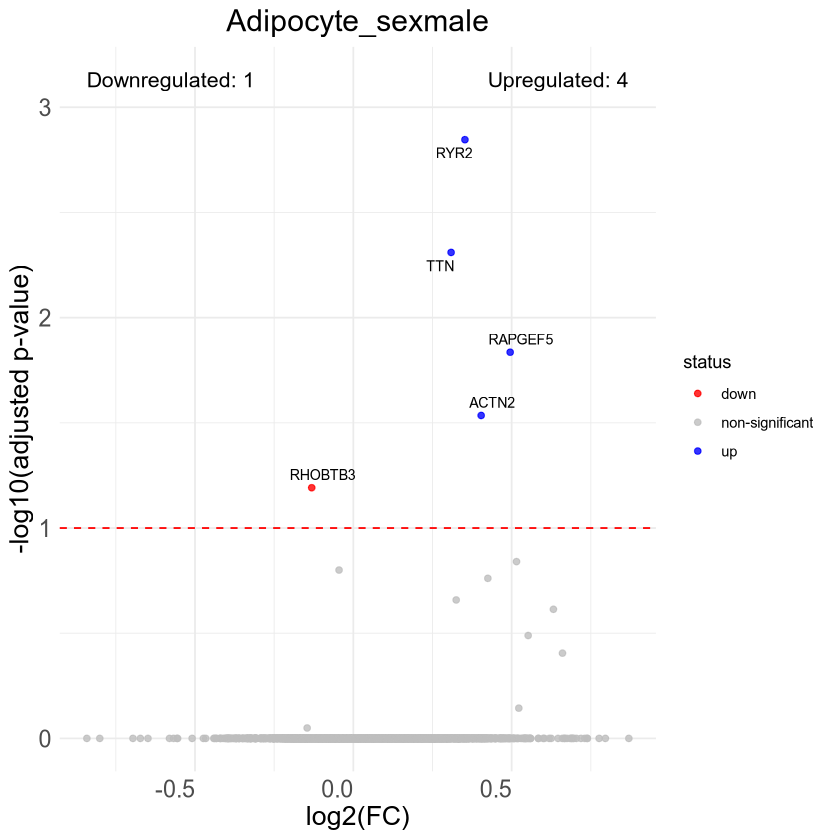

Warning message:
“ggrepel: 43 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Cardiomyocyte"


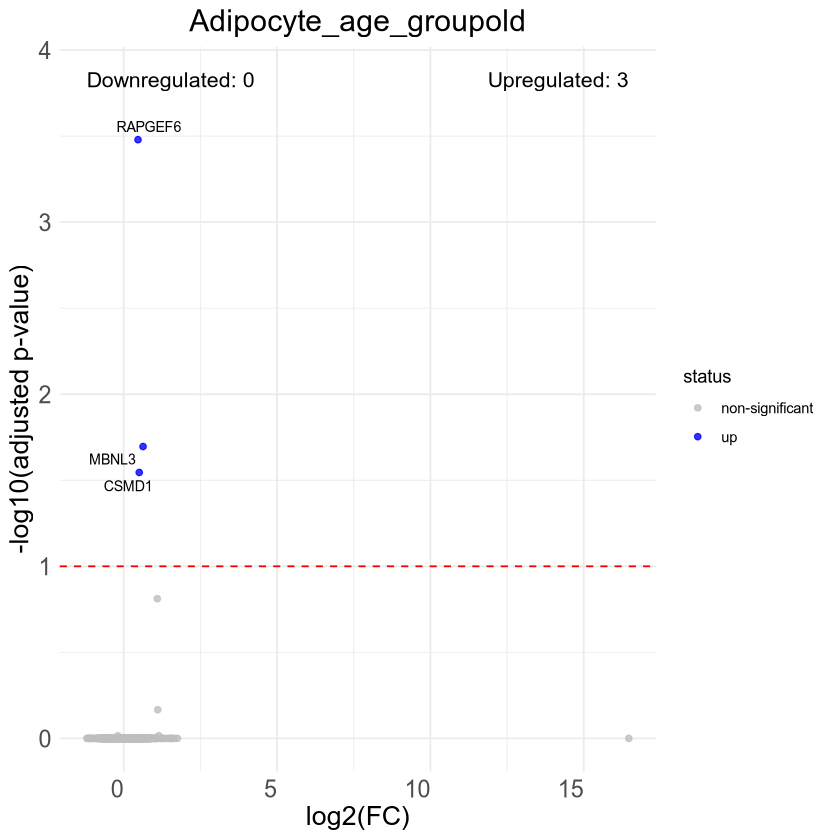

Warning message:
“ggrepel: 74 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] 0 0


Warning message:
“ggrepel: 42 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


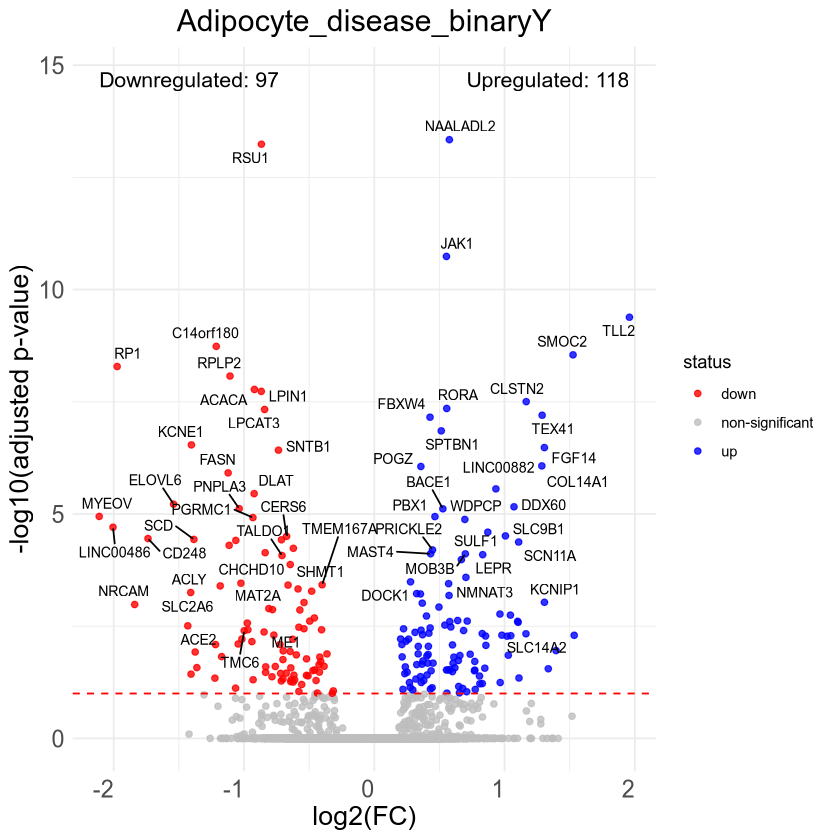

Warning message:
“ggrepel: 43 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 74 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


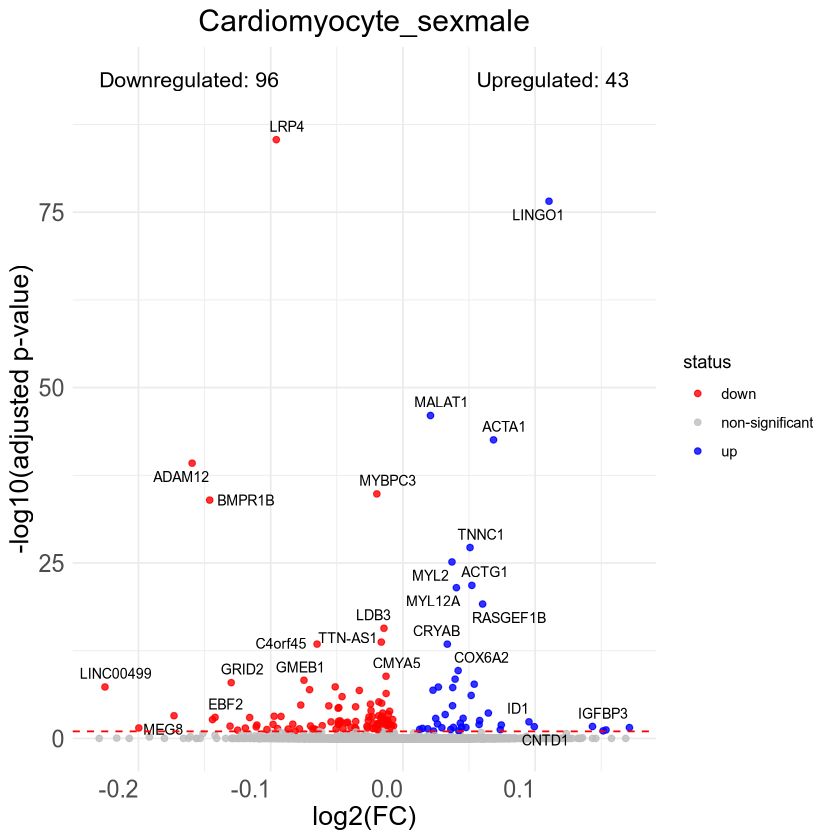

Warning message:
“ggrepel: 74 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Endocardial"


Warning message:
“ggrepel: 42 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


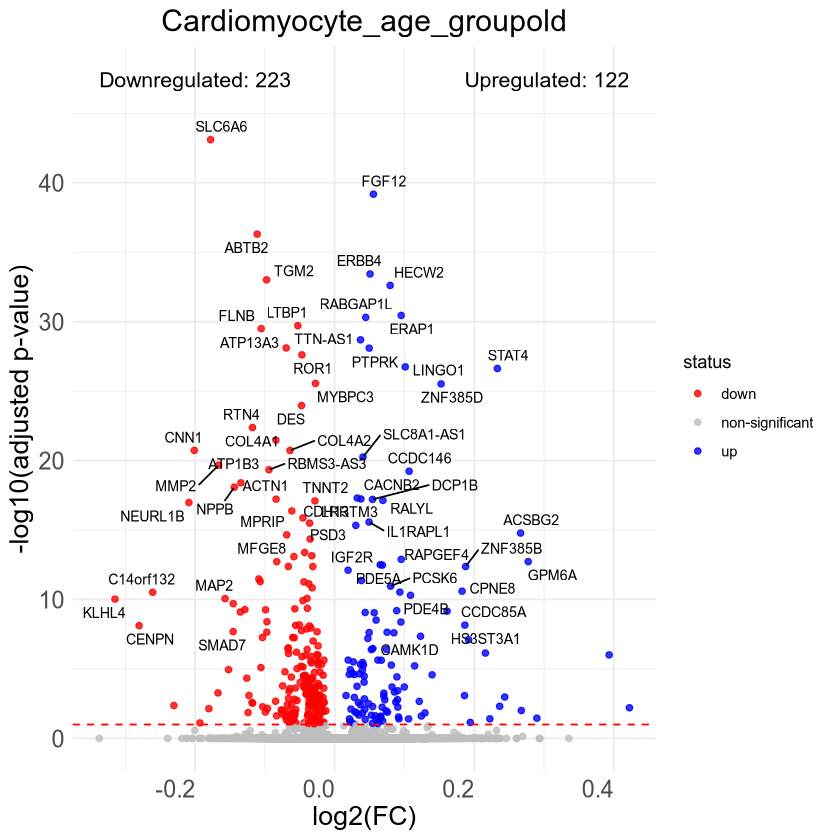

[1] 1 0


Warning message:
“ggrepel: 72 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


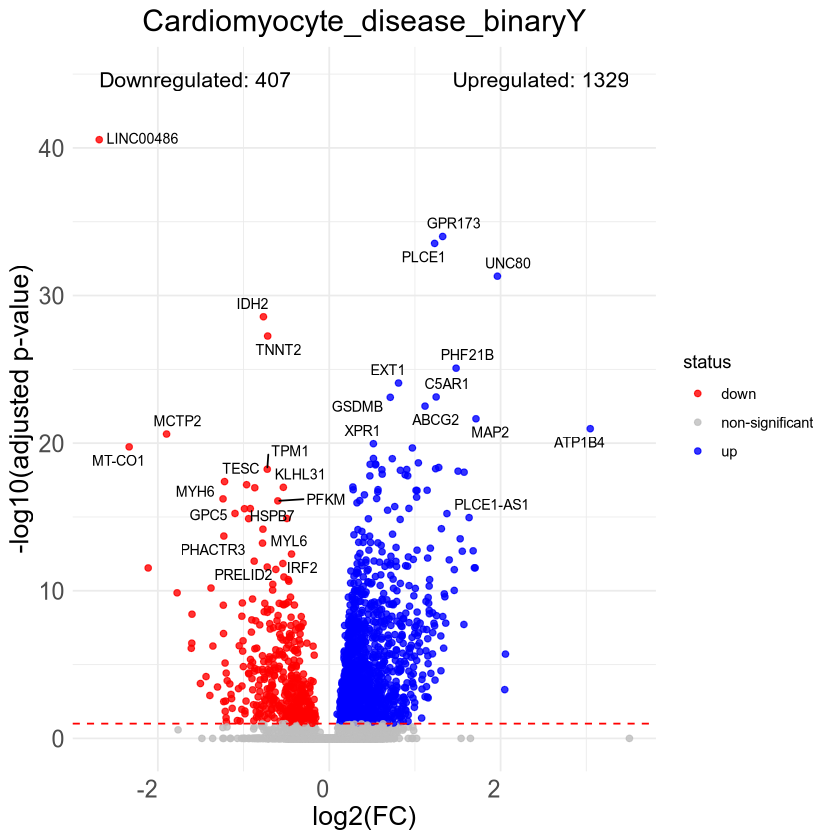

Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_hline()`).”


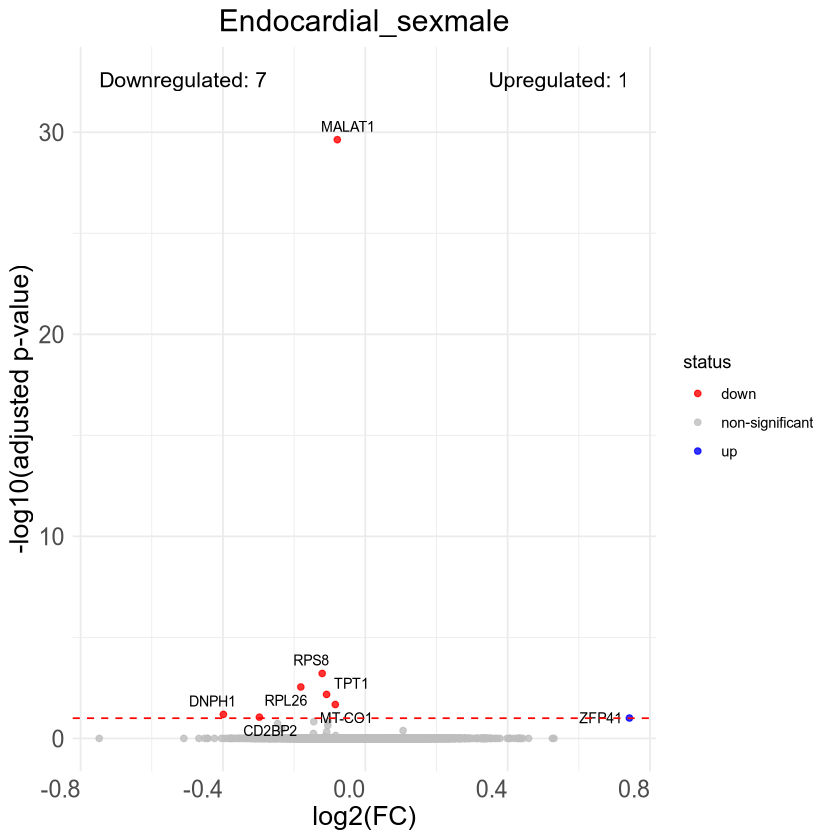

Warning message:
“ggrepel: 74 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Endothelial"


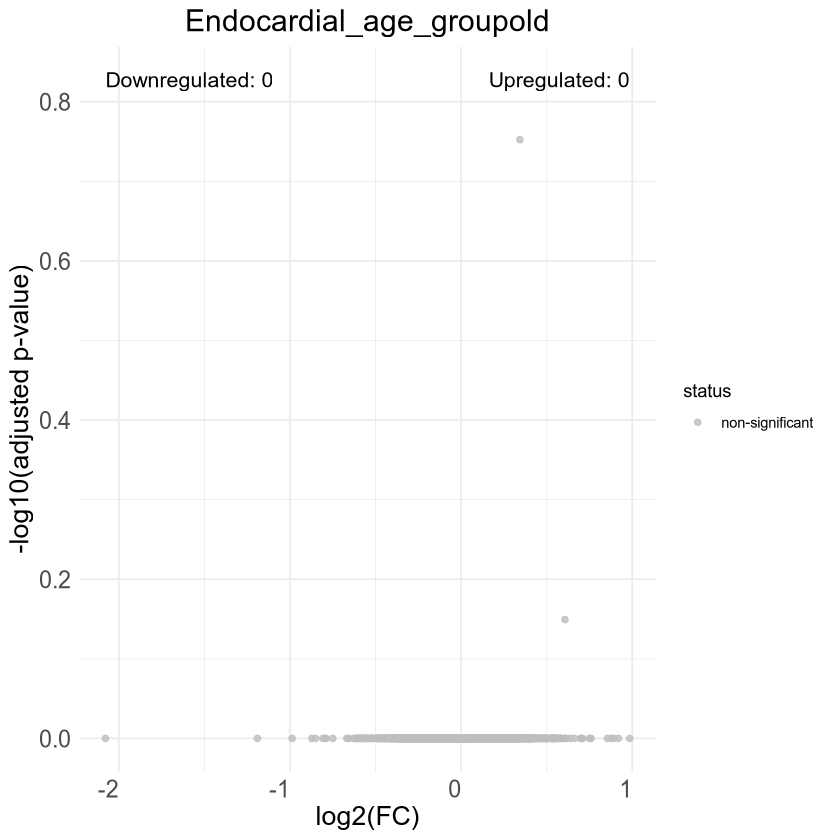

Warning message:
“ggrepel: 8 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] 0 0


Warning message:
“ggrepel: 73 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


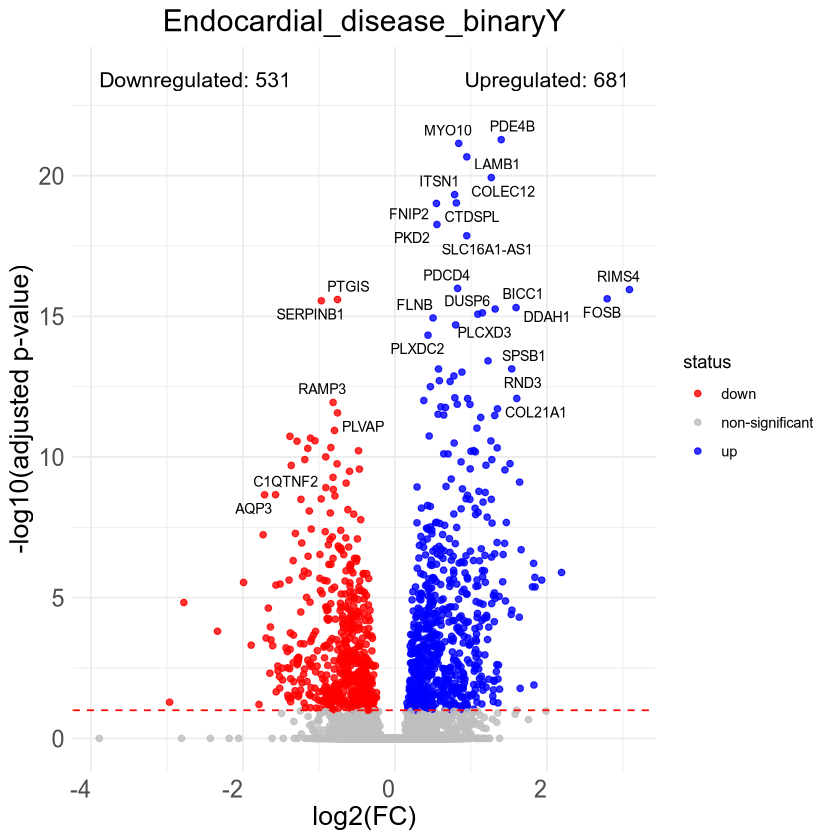

Warning message:
“ggrepel: 8 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


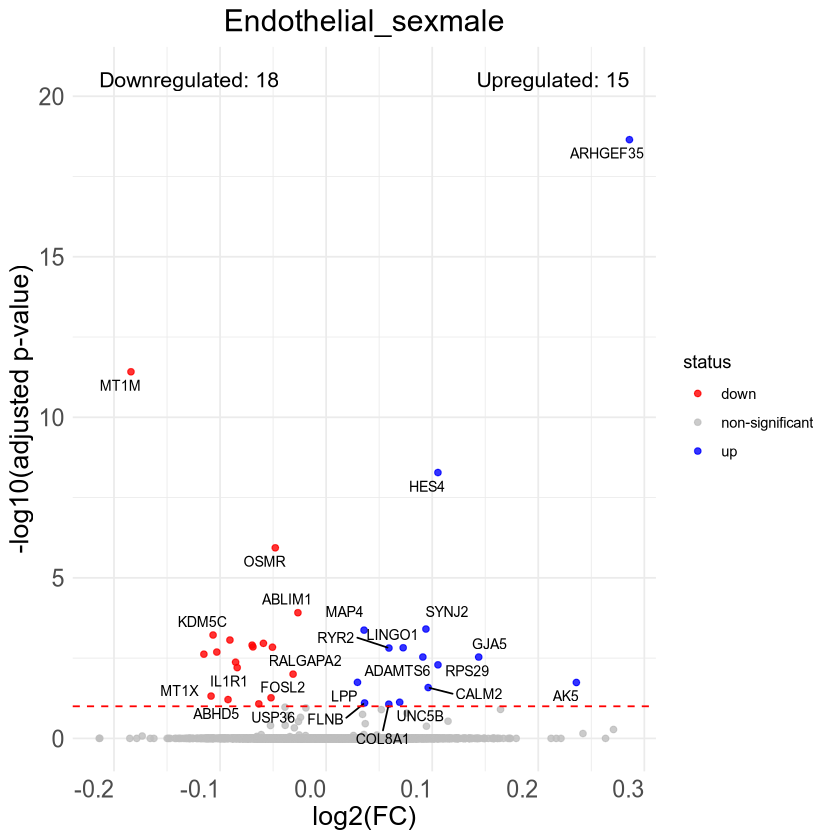

Warning message:
“ggrepel: 55 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Epicardial"


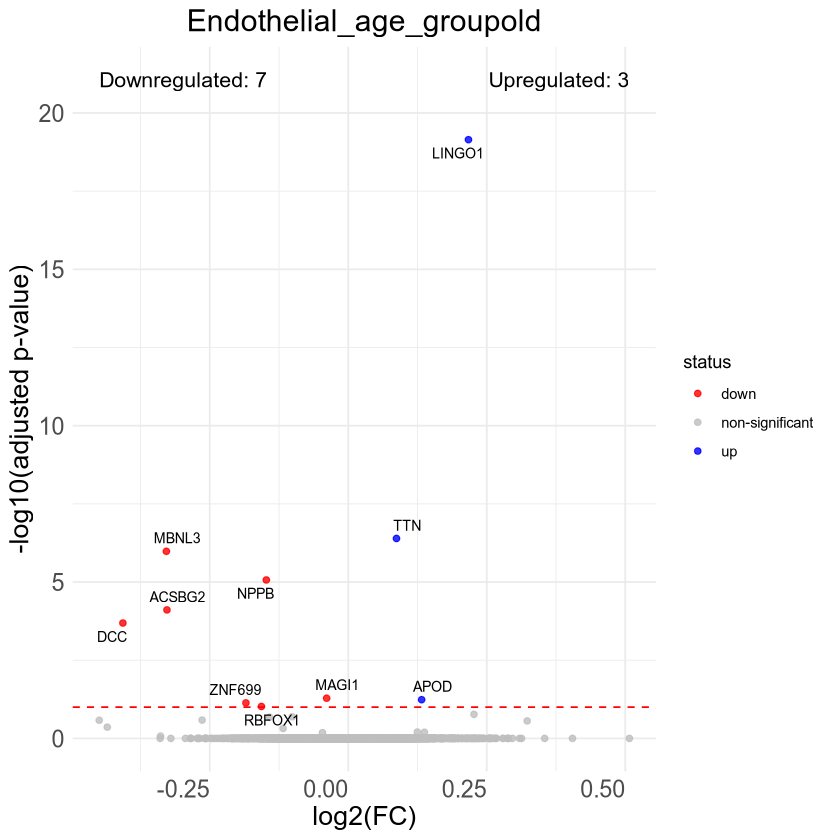

[1] 1 6


Warning message:
“ggrepel: 52 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


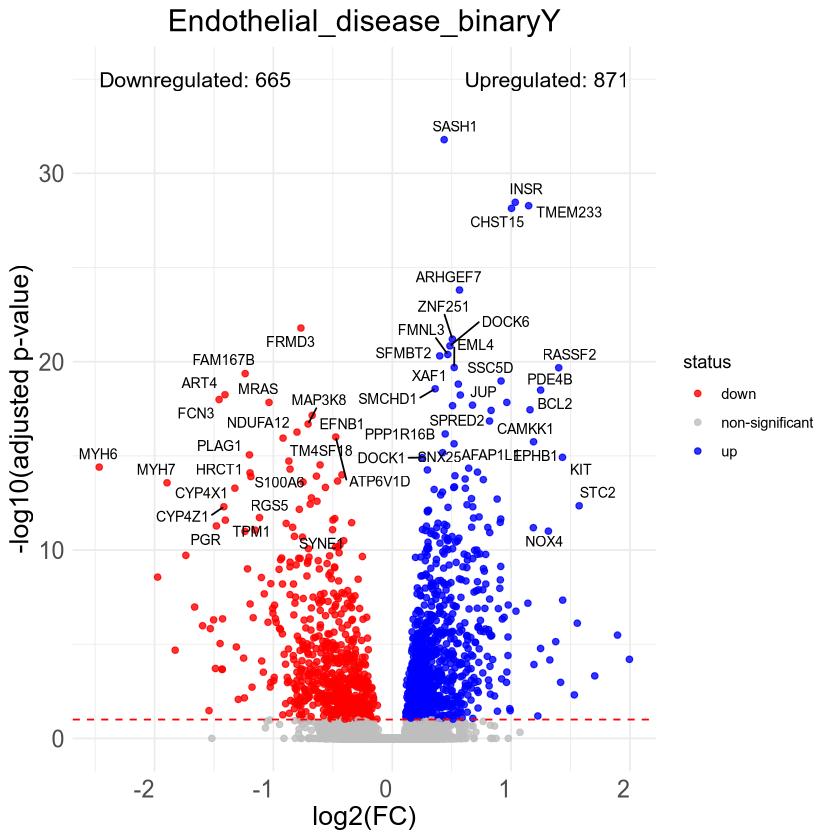

Warning message:
“ggrepel: 75 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


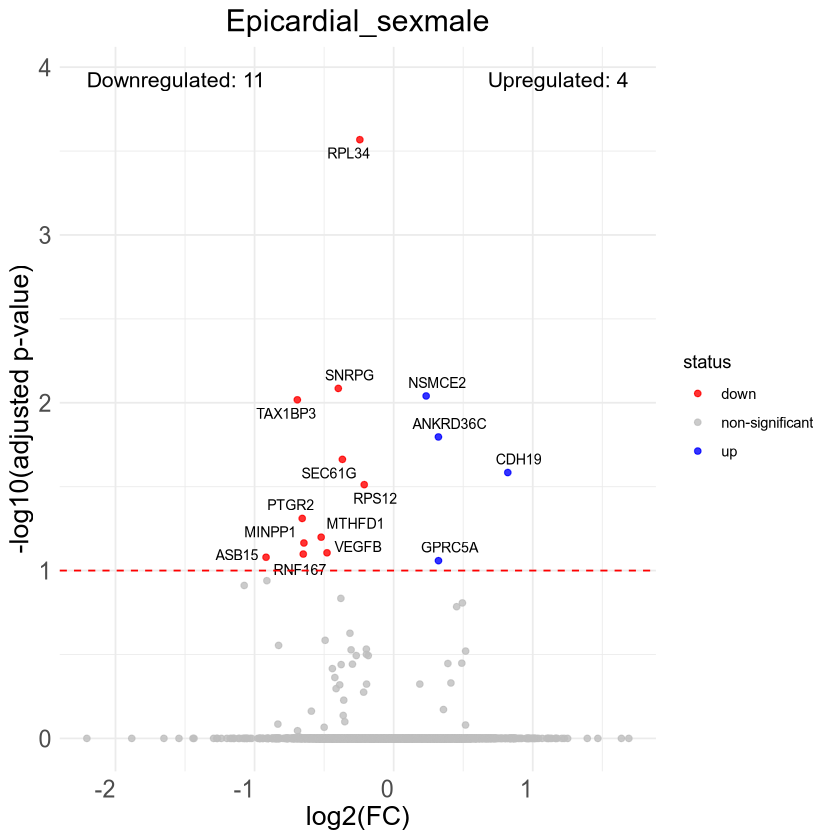

Warning message:
“ggrepel: 80 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Fibroblast"


Warning message:
“ggrepel: 75 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


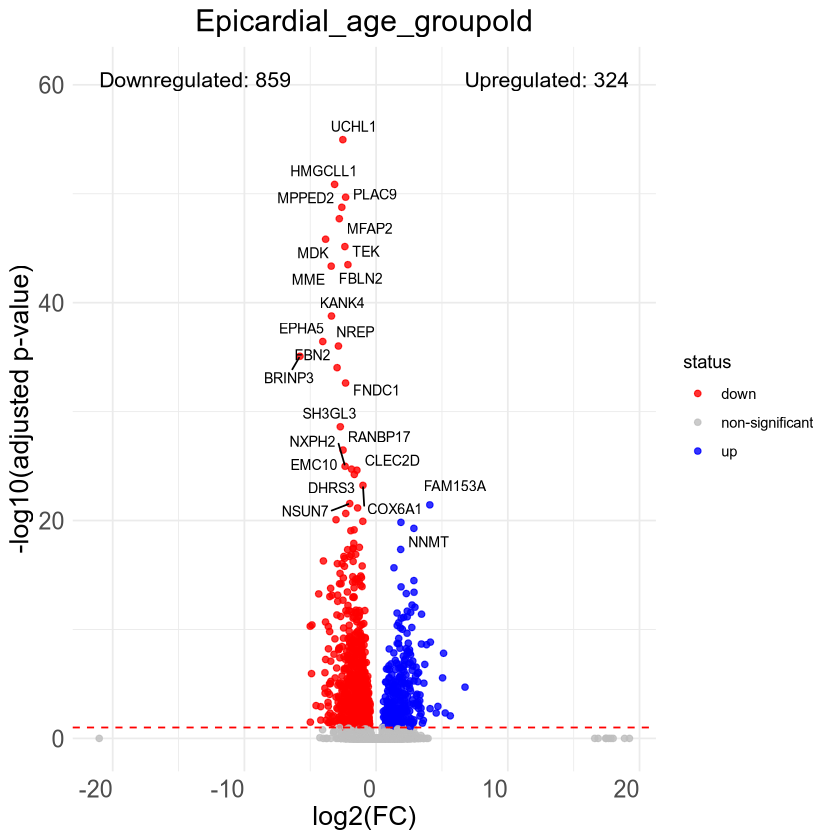

Warning message:
“ggrepel: 80 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] 0 0


Warning message:
“ggrepel: 81 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


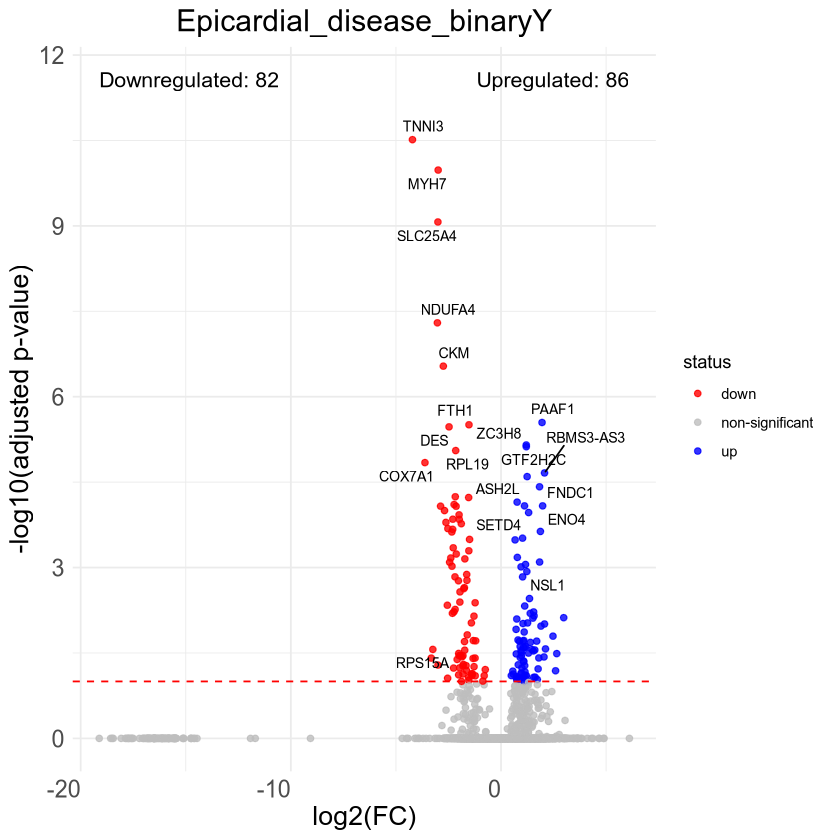

Warning message:
“ggrepel: 42 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 79 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


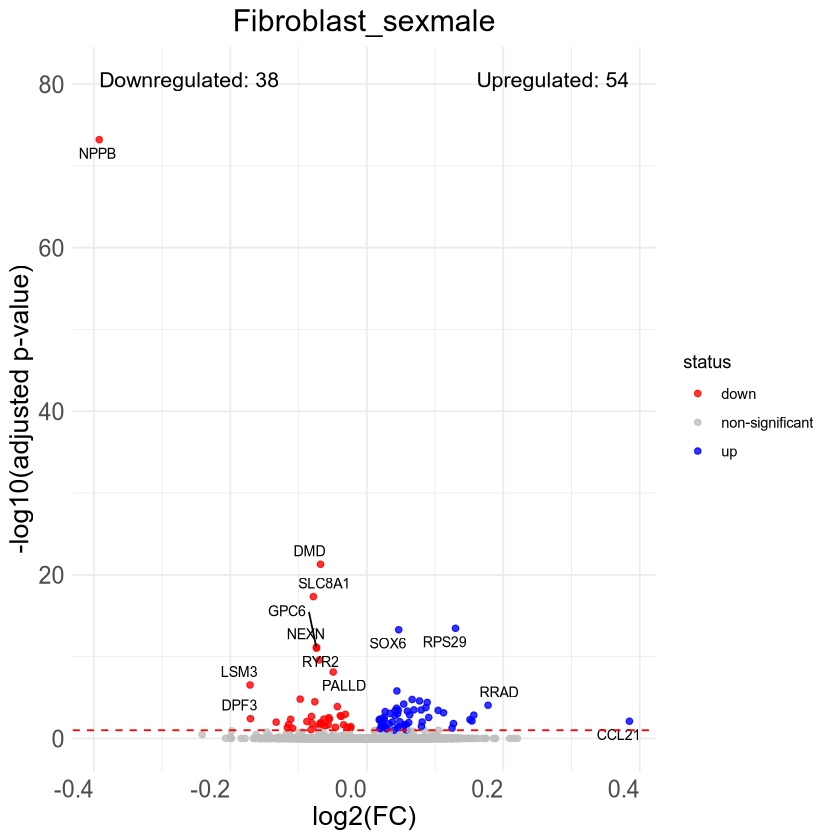

Warning message:
“ggrepel: 60 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "LEC"


Warning message:
“ggrepel: 40 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


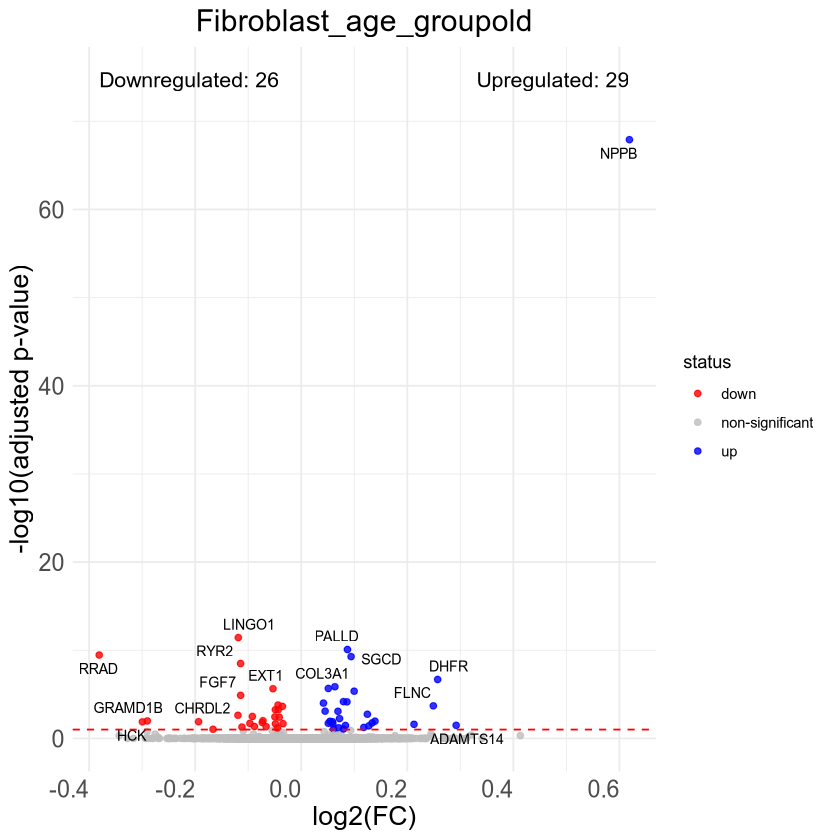

Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_hline()`).”


[1] 0 0


Warning message:
“ggrepel: 59 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


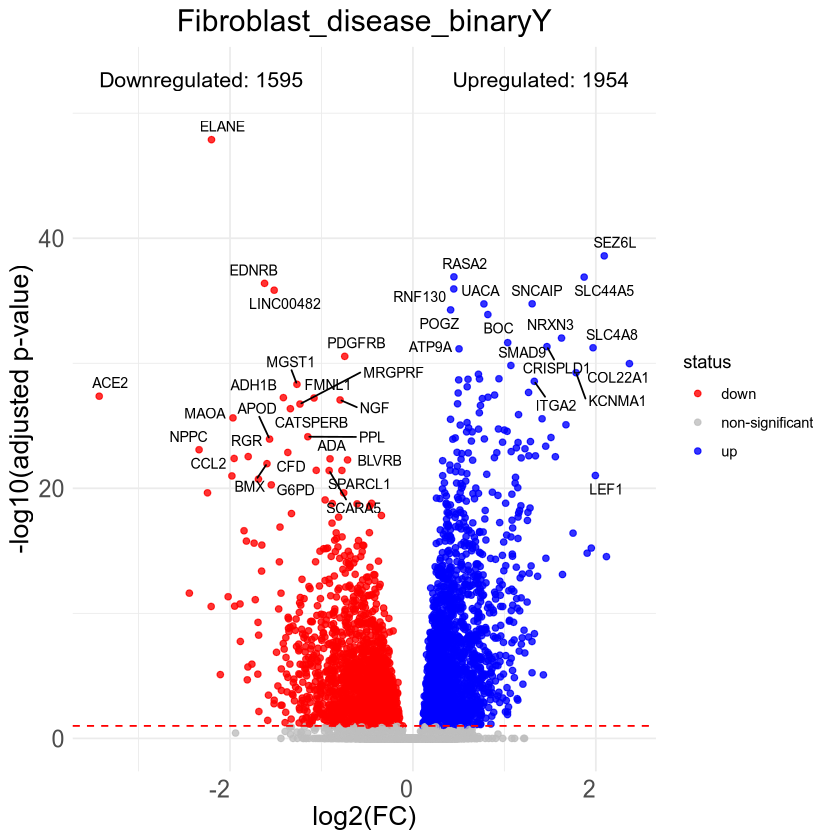

Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_hline()`).”


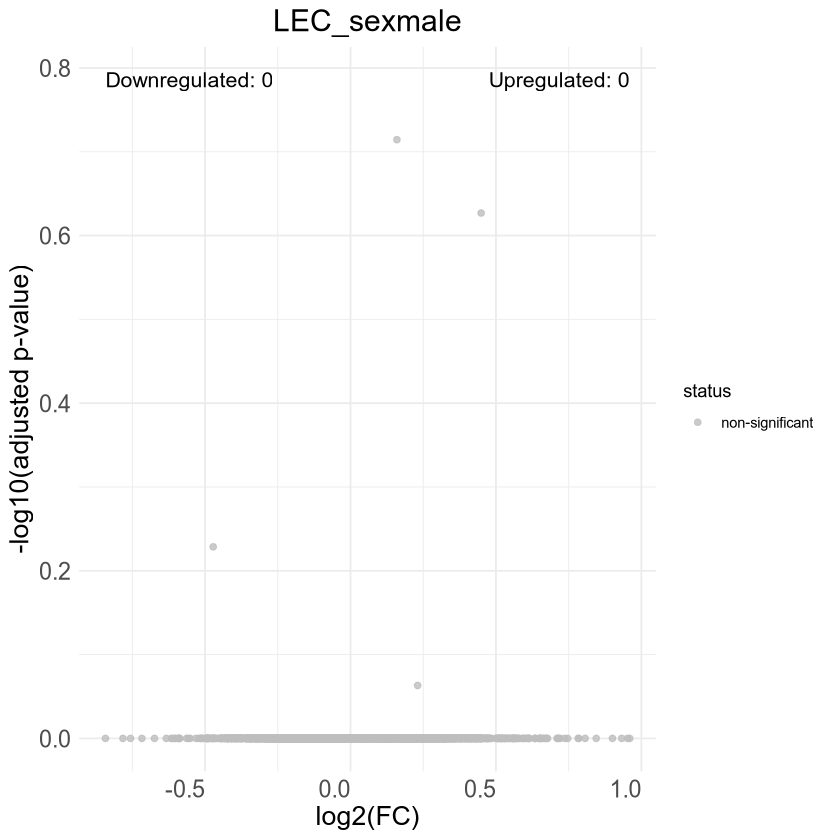

Warning message:
“ggrepel: 51 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Lymphoid"


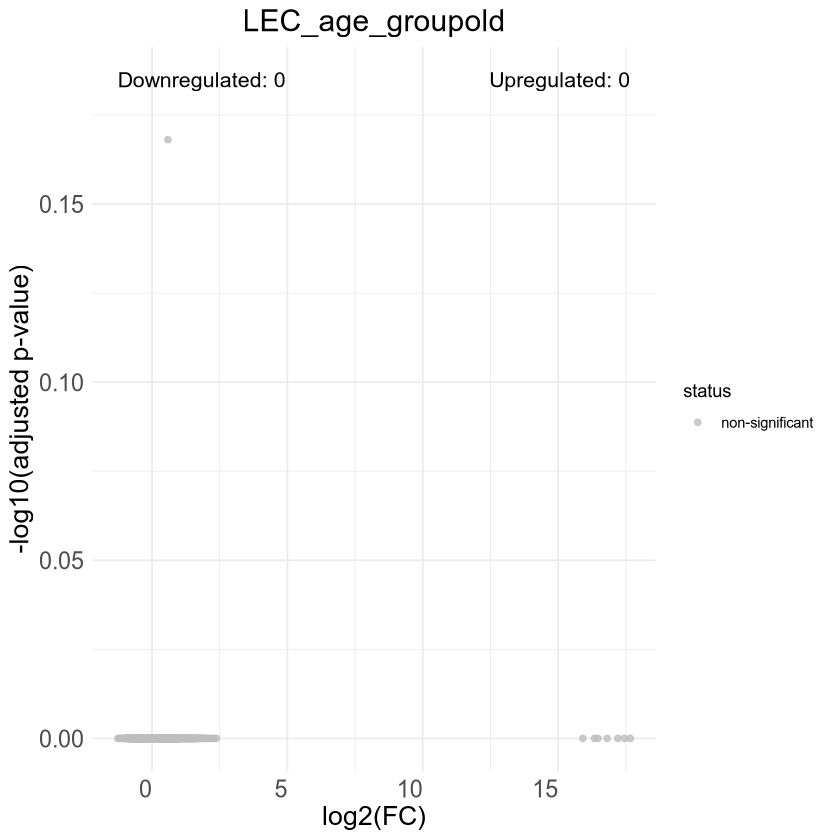

Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_hline()`).”


[1] 0 0


Warning message:
“ggrepel: 51 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


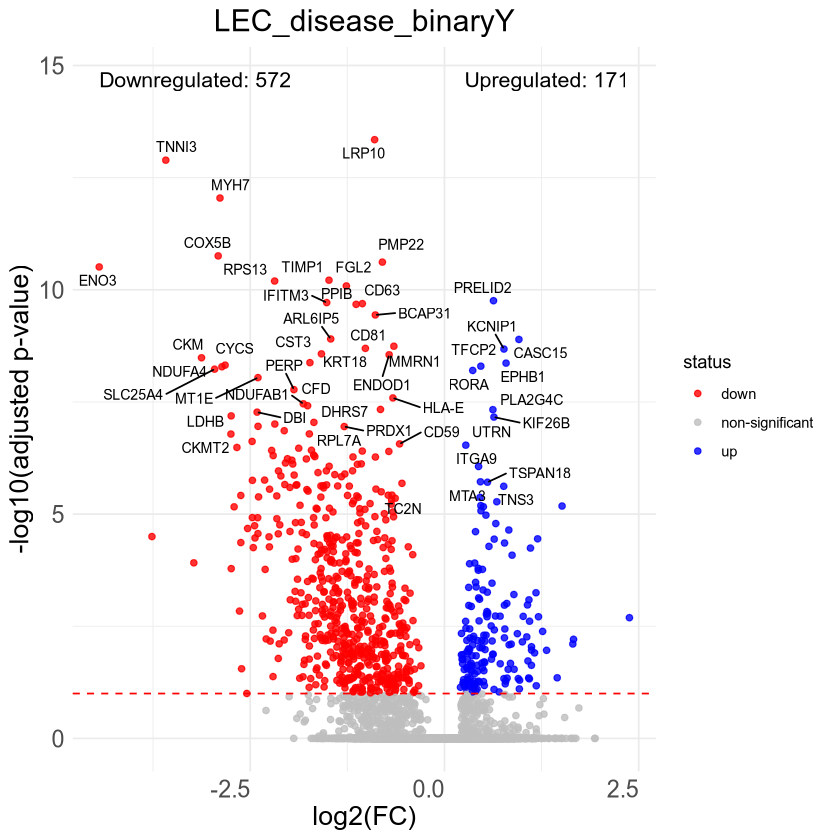

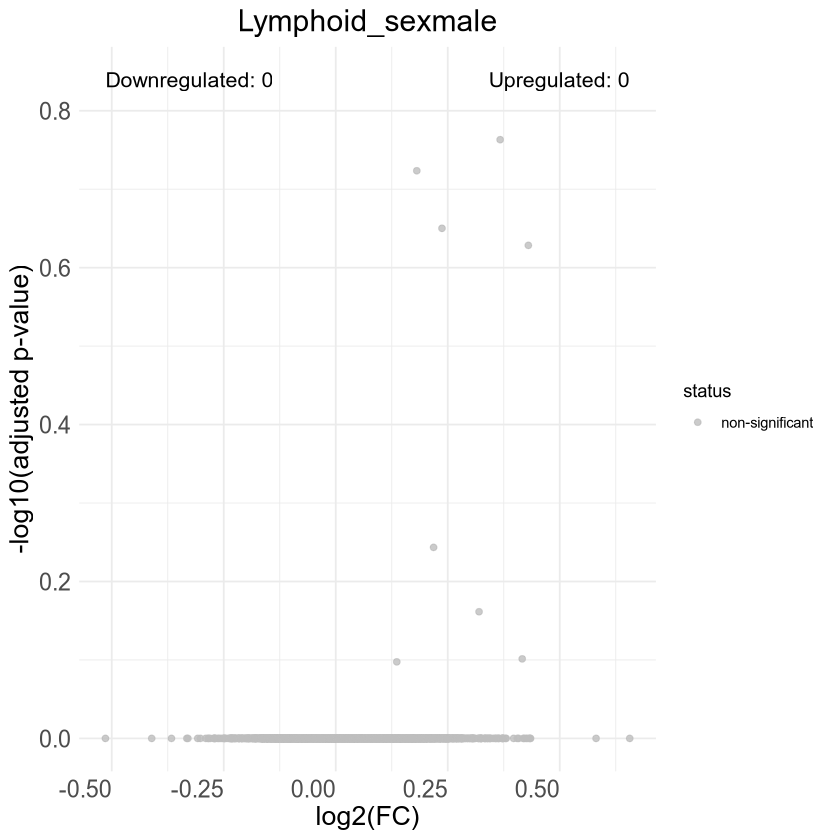

Warning message:
“ggrepel: 58 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Mast"


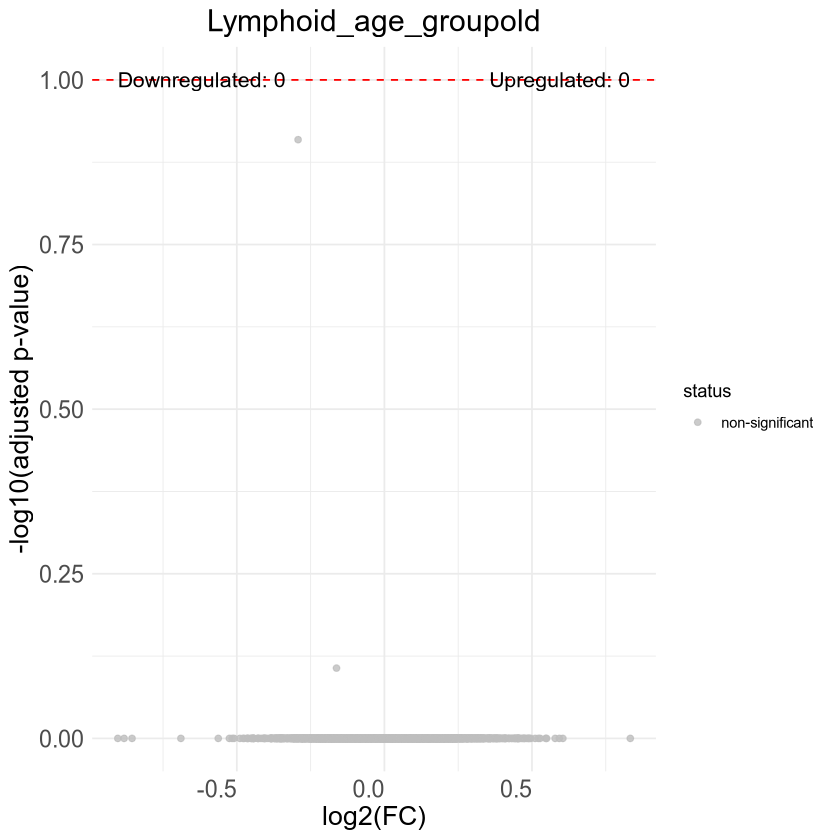

Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_hline()`).”


[1] 0 0


Warning message:
“ggrepel: 56 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


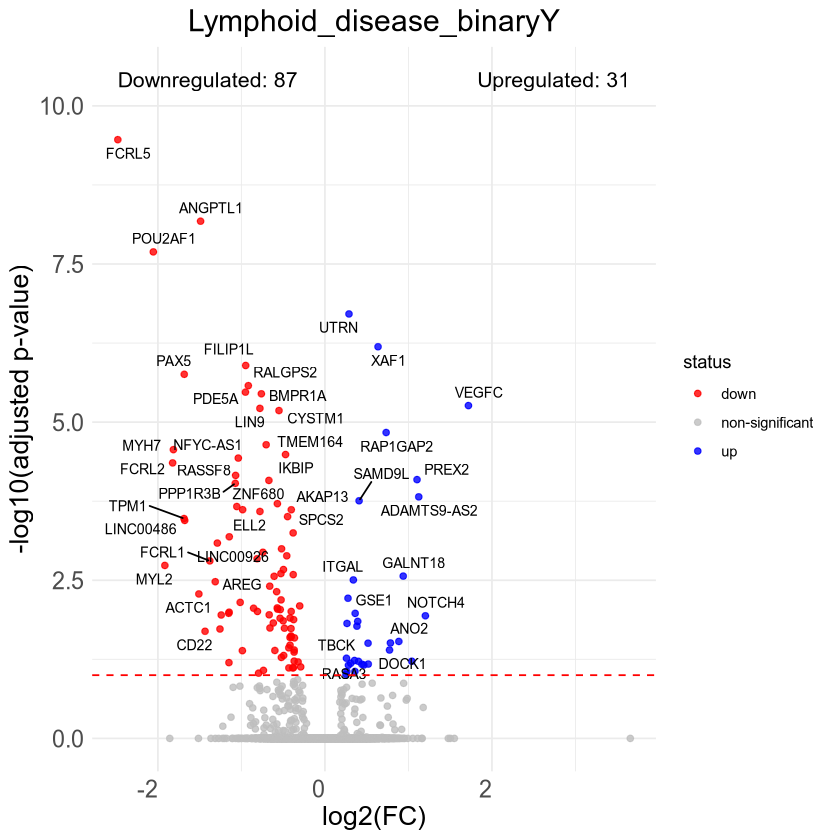

Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_hline()`).”


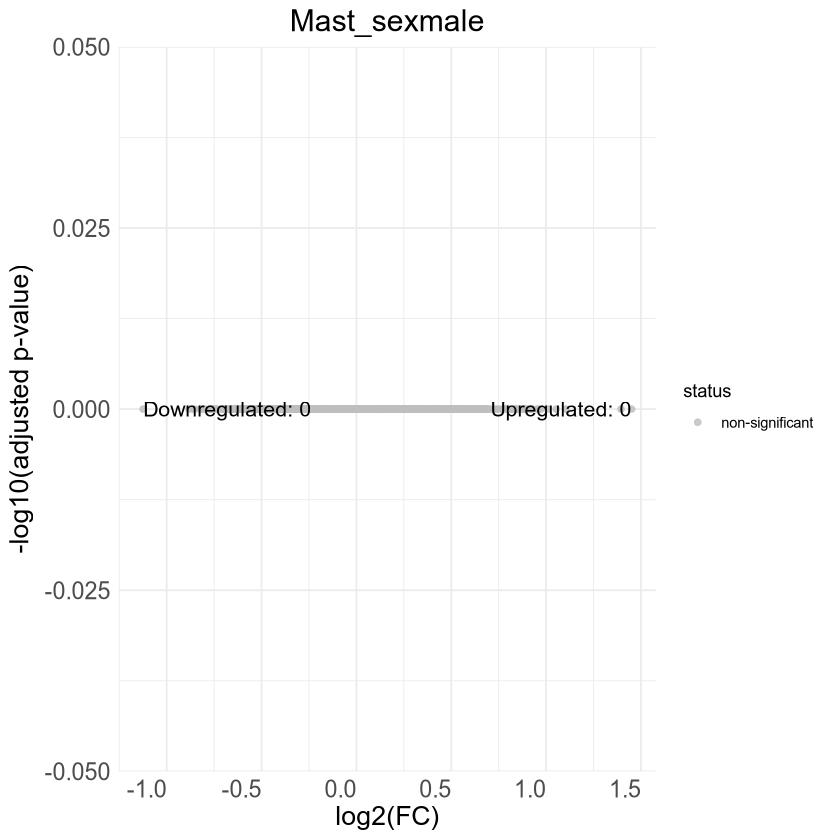

Warning message:
“ggrepel: 27 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Myeloid"


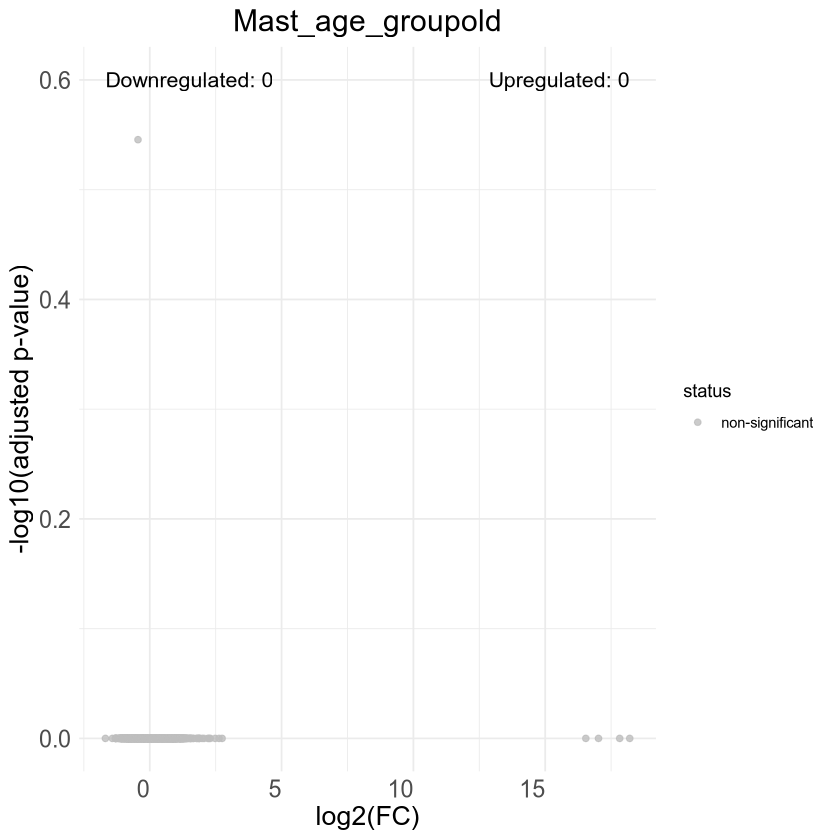

[1] 0 0


Warning message:
“ggrepel: 26 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


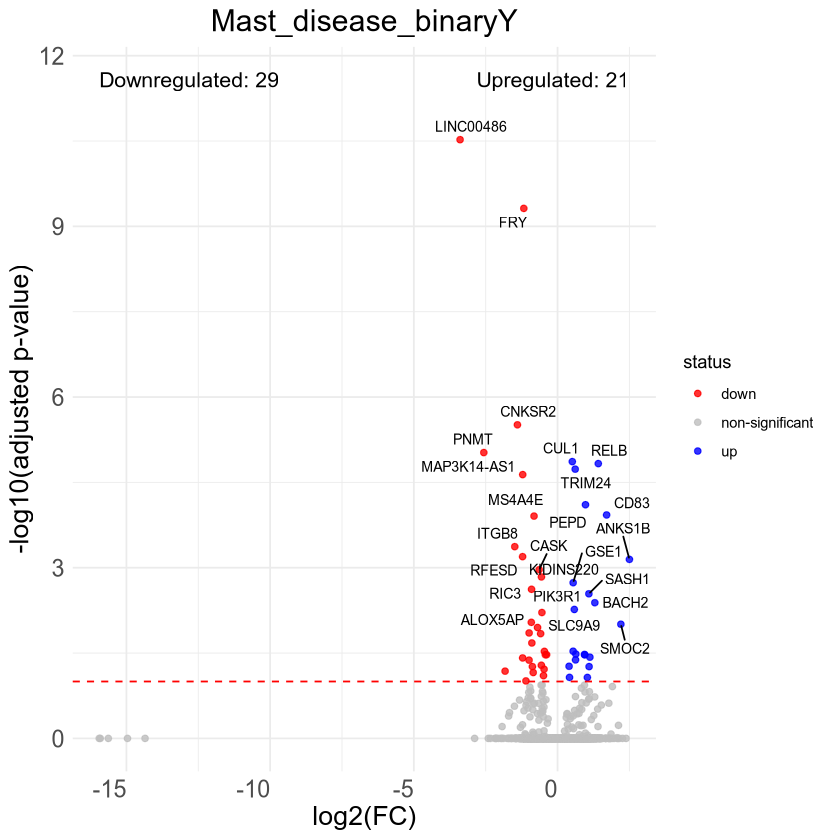

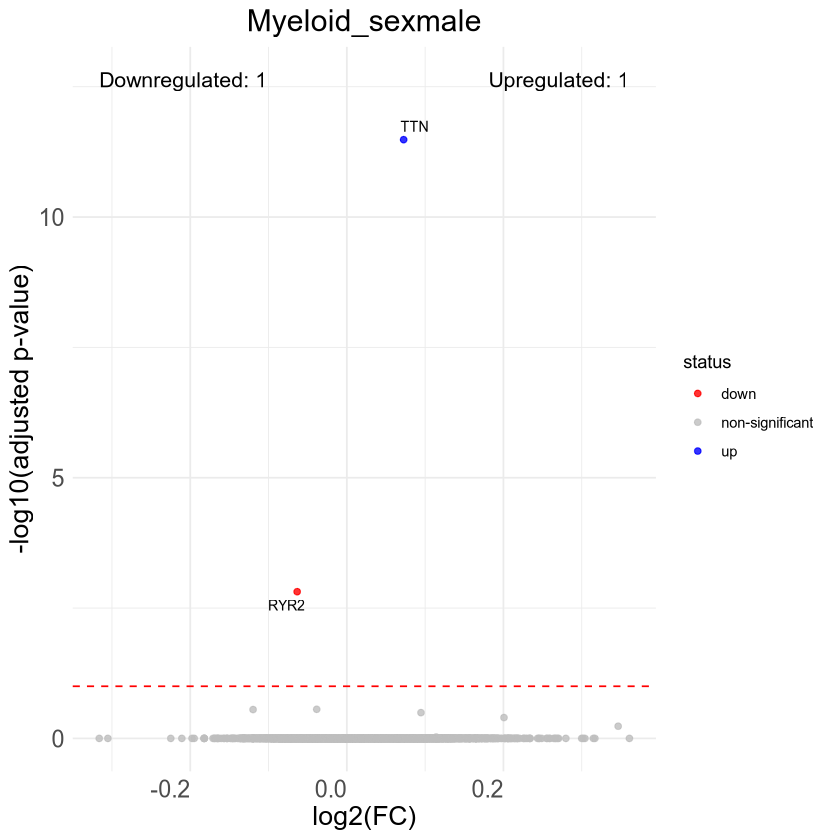

Warning message:
“ggrepel: 66 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Neuronal"


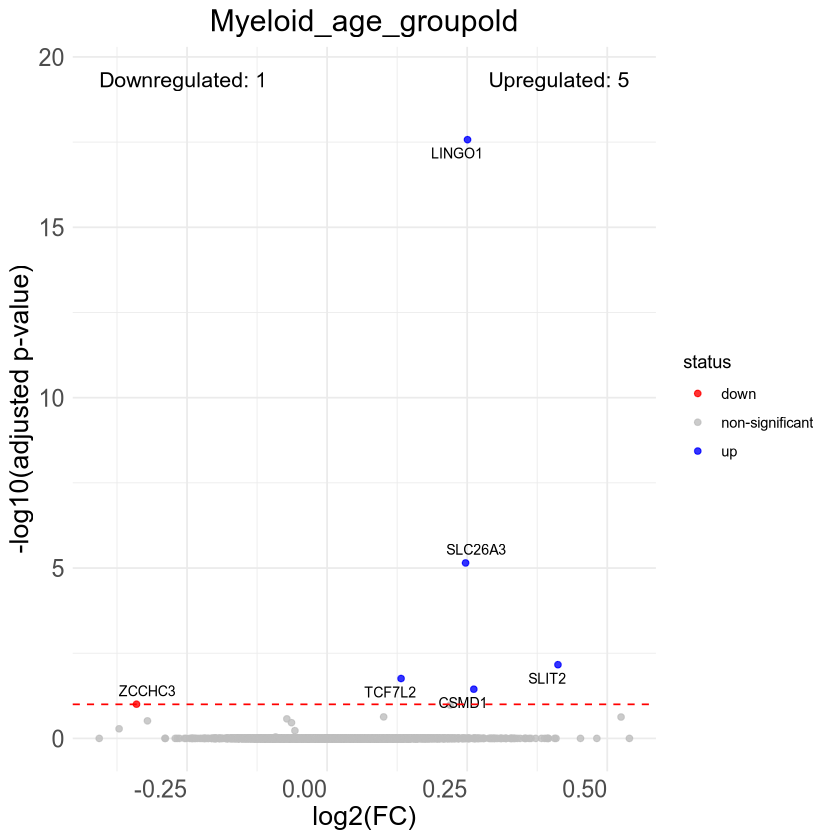

Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_hline()`).”


[1] 0 0


Warning message:
“ggrepel: 66 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


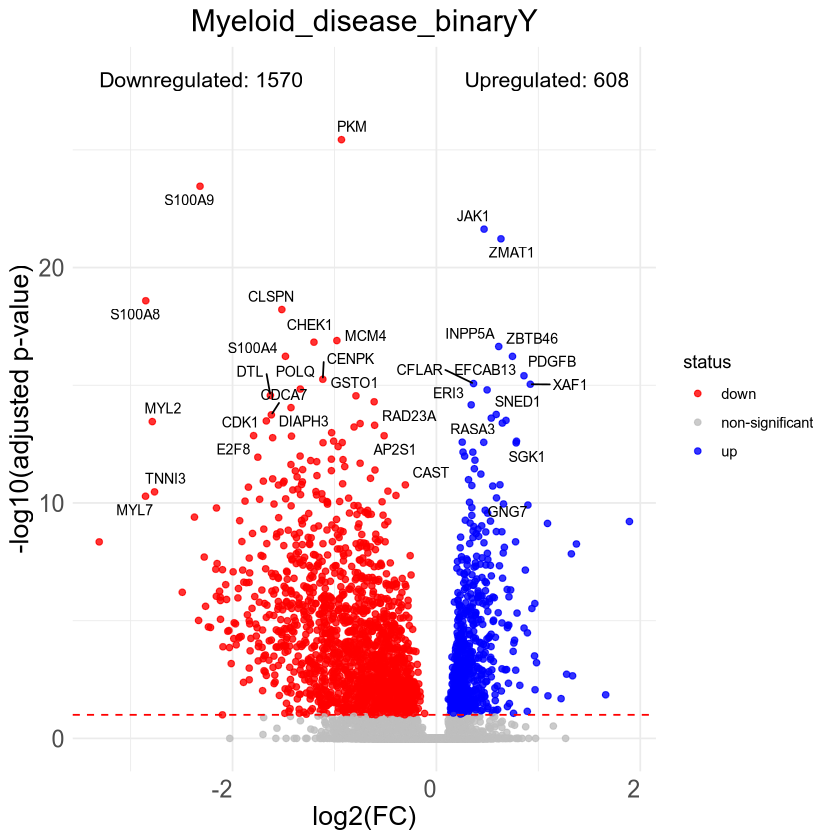

Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_hline()`).”


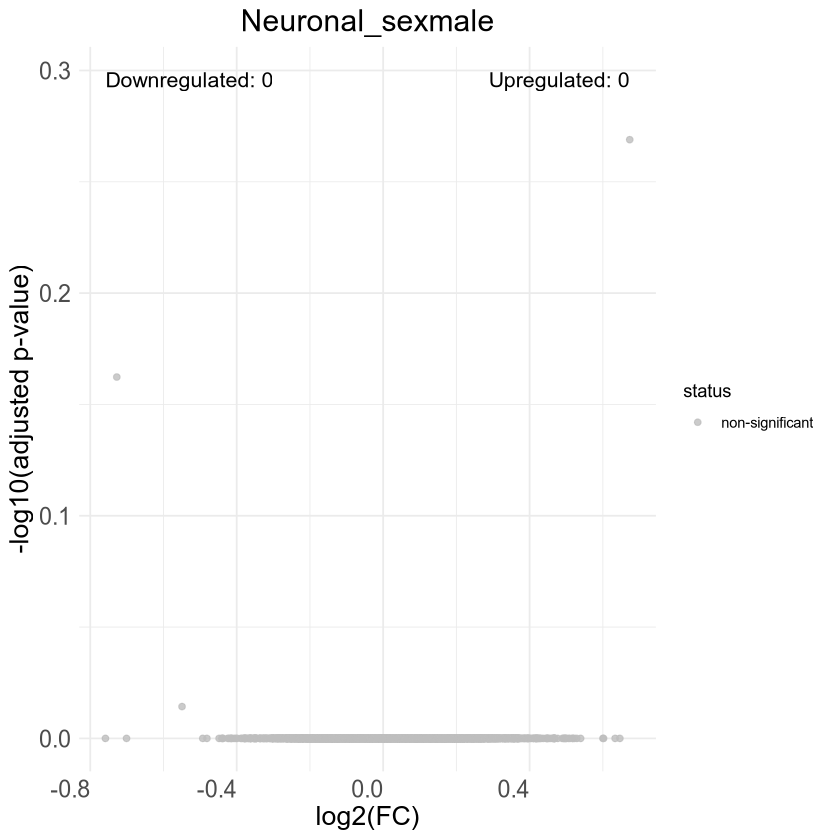

Warning message:
“ggrepel: 81 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Pericyte"


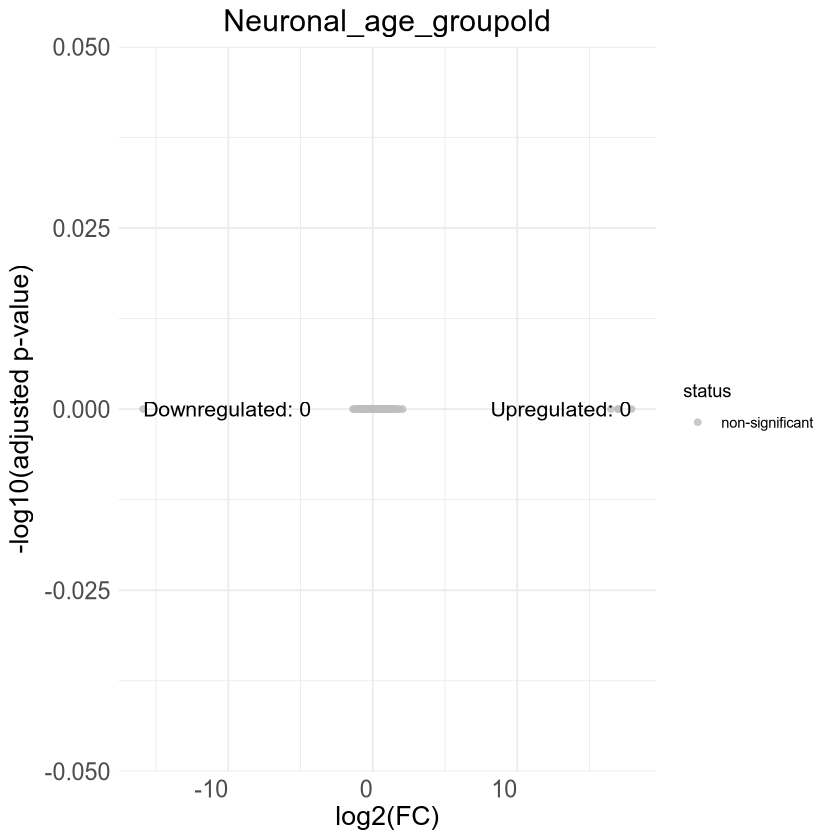

Warning message:
“ggrepel: 10 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] 0 0


Warning message:
“ggrepel: 81 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


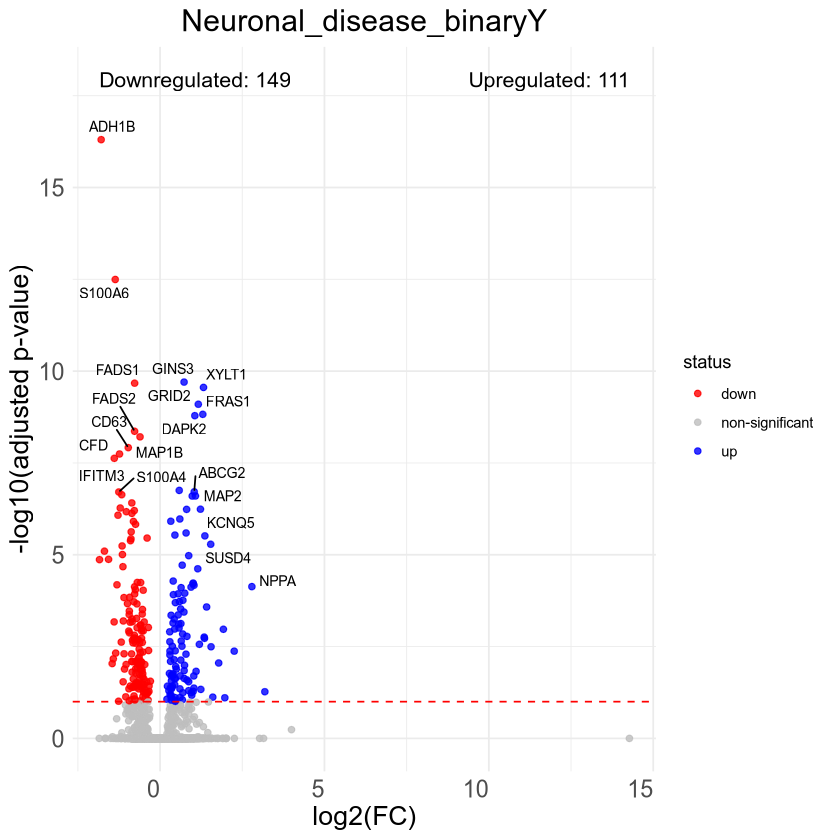

Warning message:
“ggrepel: 10 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


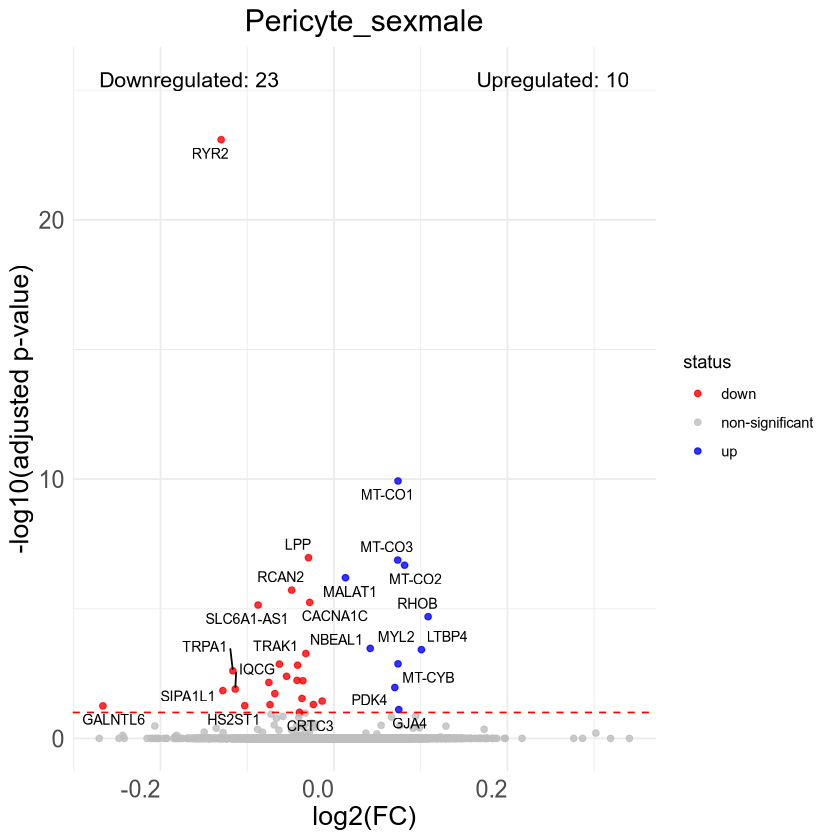

Warning message:
“ggrepel: 67 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "vSMC"


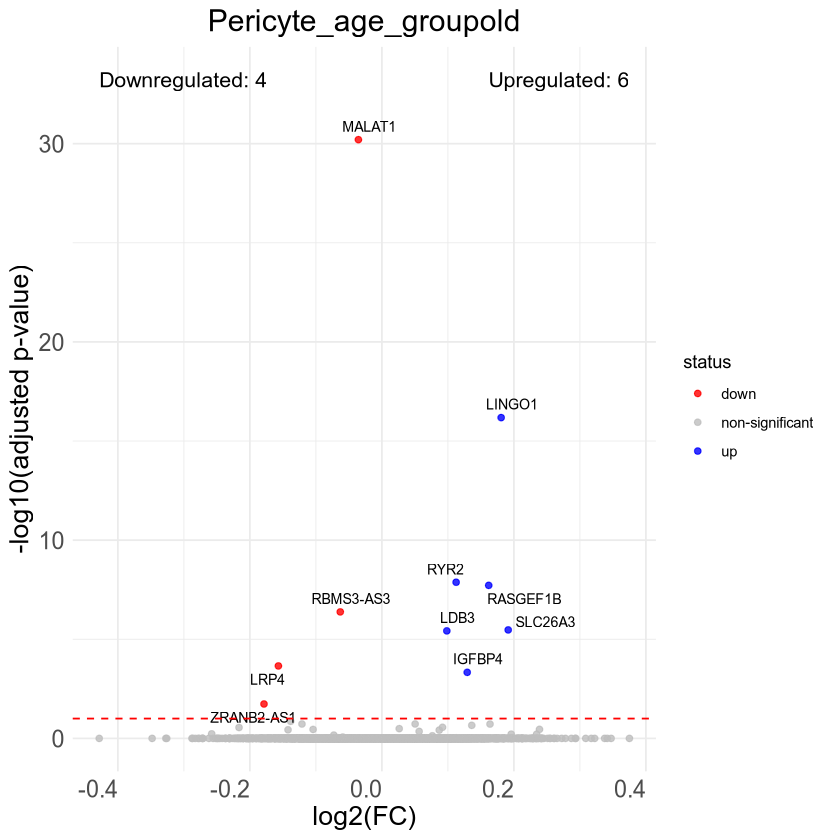

Warning message:
“ggrepel: 16 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] 1 0


Warning message:
“ggrepel: 67 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


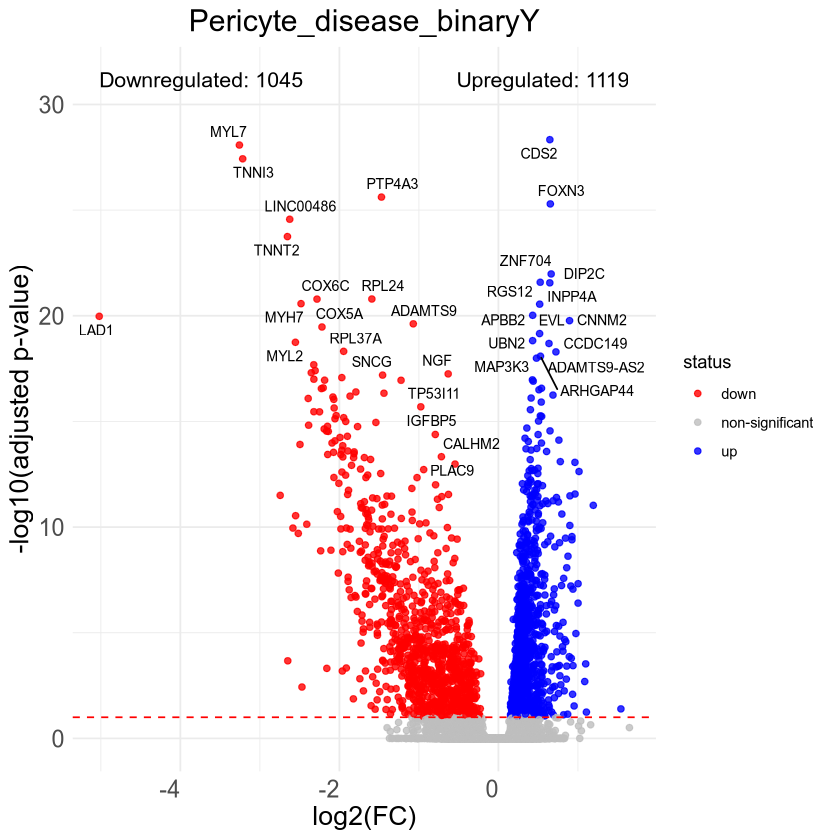

Warning message:
“ggrepel: 2 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 16 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


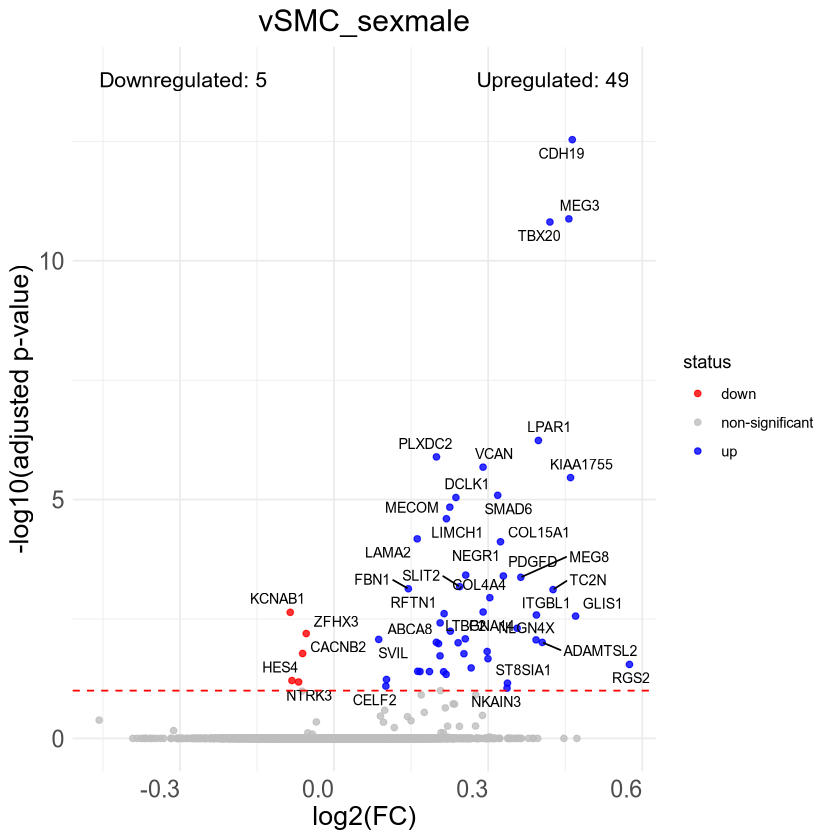

Warning message:
“ggrepel: 78 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 2 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


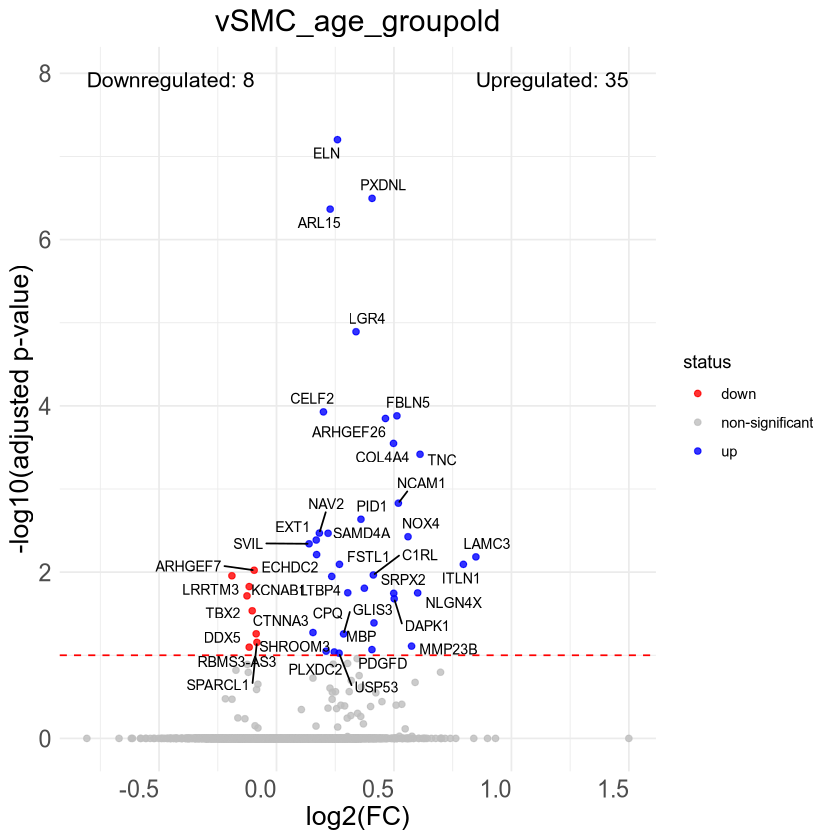

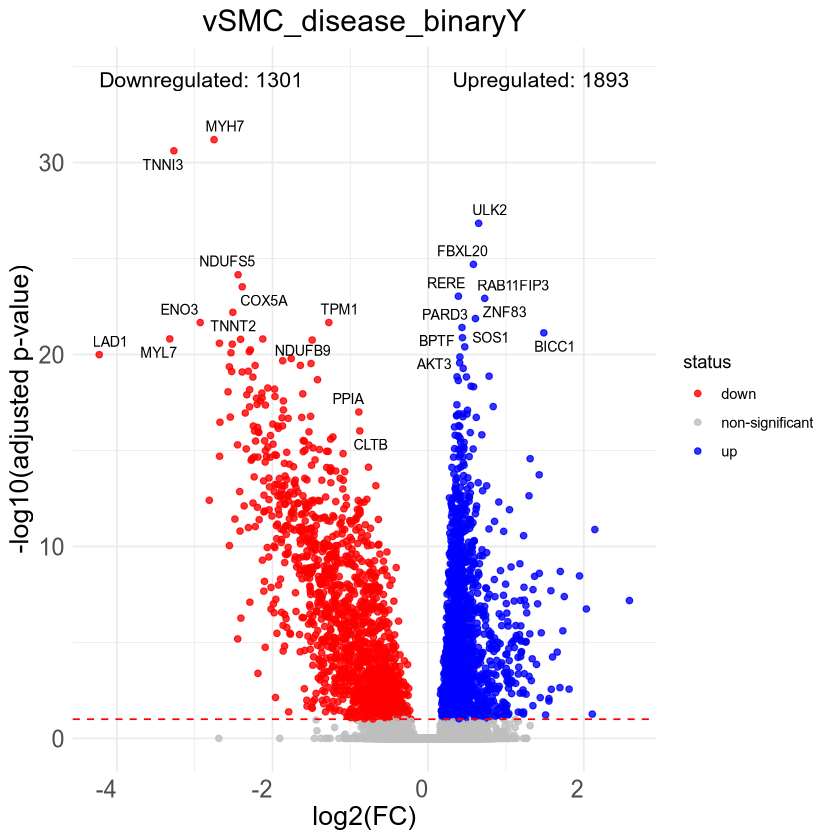

In [8]:
DE_age_up_list <- rep(0, num_cell_types)
DE_age_down_list <- rep(0, num_cell_types)
DE_sex_up_list <- rep(0, num_cell_types)
DE_sex_down_list <- rep(0, num_cell_types)

contrasts <- c("sexmale", "age_groupold", "disease_binaryY", "age_groupFetal")
p_val_thresh = 0.05

for (i in 1:num_cell_types) {

    cell_type <- cell_types[i]

    print(cell_type)
    flush.console()

    # load the in NEBULA results
    DE_fits <- readRDS(paste0("nebula_output_dir/", cell_type, ".rds"))
    # extract the df 
    DE_res <- DE_fits$summary

    # remove genes that did not converge well
    convergent_indices <- DE_fits$convergence >= -10
    filt_DE_res <- DE_res[convergent_indices, ]

    # perform the BH correction
    filt_DE_res$p_adj_age_groupold <- p.adjust(filt_DE_res$p_age_groupold)
    filt_DE_res$p_adj_age_groupFetal <- p.adjust(filt_DE_res$p_age_groupFetal)
    filt_DE_res$p_adj_sexmale <- p.adjust(filt_DE_res$p_sexmale)
    filt_DE_res$p_adj_disease_binaryY <- p.adjust(filt_DE_res$p_disease_binaryY)
    
    for (contrast in contrasts) {
        p1 <- plot_volcano(filt_DE_res, number_of_marker_genes = 100, 
                           title = paste0(cell_type, "_", contrast), 
                           contrast = contrast)
        print(p1)
        
        if (contrast == "sexmale") {
            FC_thresh = 0.5
            
            n_DE_genes <- count_DE_genes(DE_res = filt_DE_res, 
                                         FC_threshold = FC_thresh,
                                         p_adj_threshold = p_val_thresh, 
                                         contrast)

            print(n_DE_genes)
            flush.console()
            DE_sex_up_list[i] <- n_DE_genes[1]
            DE_sex_down_list[i] <- n_DE_genes[2]
        }
        
        else if (contrast == "age") {
            FC_thresh = 0.5

            n_DE_genes <- count_DE_genes(DE_res = filt_DE_res, 
                                         FC_threshold = FC_thresh,
                                         p_adj_threshold = p_val_thresh, 
                                         contrast)

            print(n_DE_genes)
            flush.console()
            
            DE_age_up_list[i] <- n_DE_genes[1]
            DE_age_down_list[i] <- n_DE_genes[2]
        }
        
    }
}

It appears that the sex-specific genes are not longer differentially expressed?

In [19]:
CM_res <- readRDS(paste0("nebula_output_dir/Cardiomyocyte.rds"))

In [20]:
CM_res$summary %>% filter(gene == "XIST") %>% select(`p_sexmale`)

p_sexmale
<dbl>
7.762452e-06


### Display the results in a plot

In [13]:
overall_results_tibble <- tibble(`cell_type` = cell_types,
                                `age_up` = DE_age_up_list,
                                `age_down` = DE_age_down_list,
                                `sex_up` = DE_sex_up_list,
                                `sex_down` = DE_sex_down_list)
overall_results_tibble

cell_type,age_up,age_down,sex_up,sex_down
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Adipocyte,0,0,0,0
Cardiomyocyte,0,0,0,0
Endocardial,0,0,1,0
Endothelial,0,0,0,0
Epicardial,0,0,1,6
Fibroblast,0,0,0,0
LEC,0,0,0,0
Lymphoid,0,0,0,0
Mast,0,0,0,0


In [14]:
# make this tidy
age_tidy_df <- overall_results_tibble %>% select("cell_type", "age_up", "age_down") %>% pivot_longer(cols = starts_with("age_"), 
               names_to = c("condition", "direction"), 
               names_sep = "_", 
               values_to = "count")  %>%
  mutate(condition = "age")

sex_tidy_df <- overall_results_tibble %>%  select("cell_type", "sex_up", "sex_down") %>%
      pivot_longer(cols = starts_with("sex_"), 
                   names_to = c("condition", "direction"), 
                   names_sep = "_", 
                   values_to = "count") %>%
      mutate(condition = "sex")

In [15]:
# add the bar plot values directly above the bars
barplot_with_text <- function(plot_data, condition_title) {
  ggplot(plot_data, aes(x = cell_type, y = count, fill = direction)) +
    geom_bar(stat = "identity", position = position_dodge()) +
    geom_text(aes(label = count), vjust = -0.5, position = position_dodge(width = 0.9), size = 5) +  # Adding text labels
    labs(title = condition_title, x = "cell type", y = "number of genes") +
    scale_fill_manual(values = c("up" = "blue", "down" = "red")) +
    theme_minimal() + theme(legend.text = element_text(size = 16), 
         legend.title = element_text(size = 16), 
         plot.title = element_text(size = 24, hjust = 0.5), 
         axis.title.x = element_text(size = 16),
         axis.title.y = element_text(size = 16),
         axis.text.x = element_text(size = 16),
         axis.text.y = element_text(size = 16)) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))
}

### Produce barplots 

In [16]:
options(repr.plot.width = 8, repr.plot.height = 8)

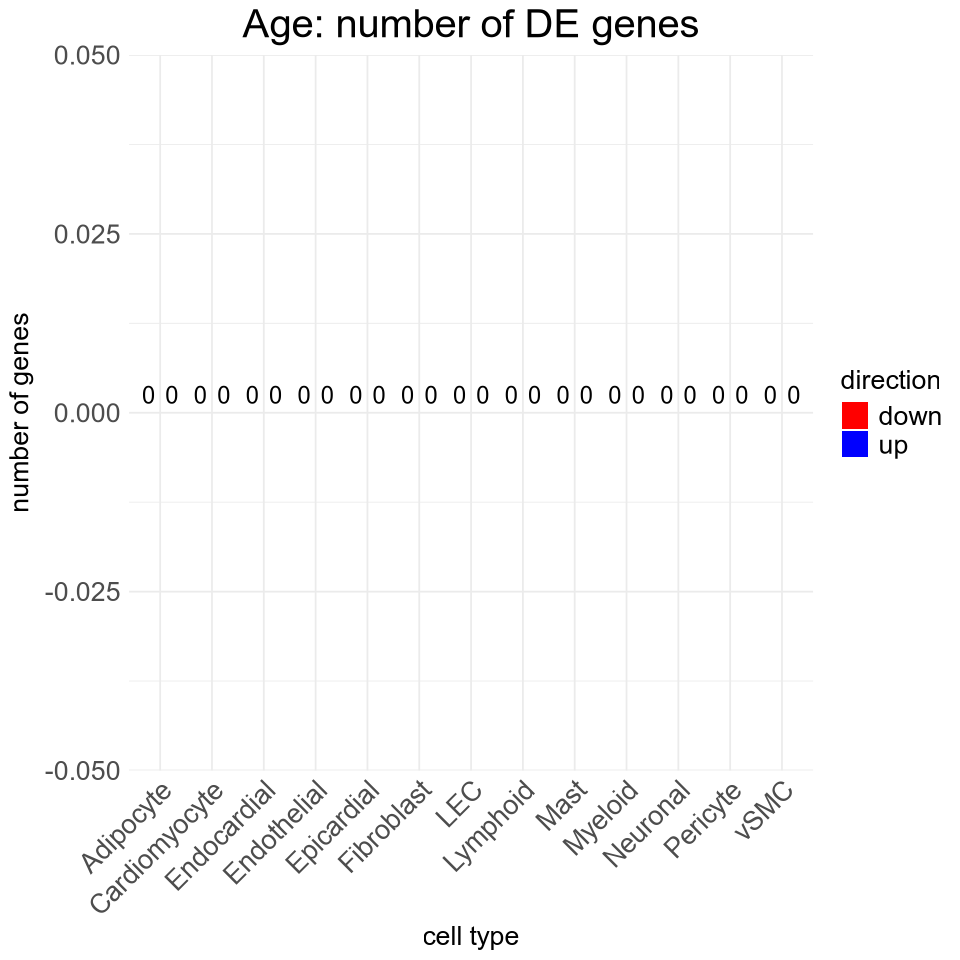

In [17]:
age_plot <- barplot_with_text(age_tidy_df, "Age: number of DE genes")
age_plot

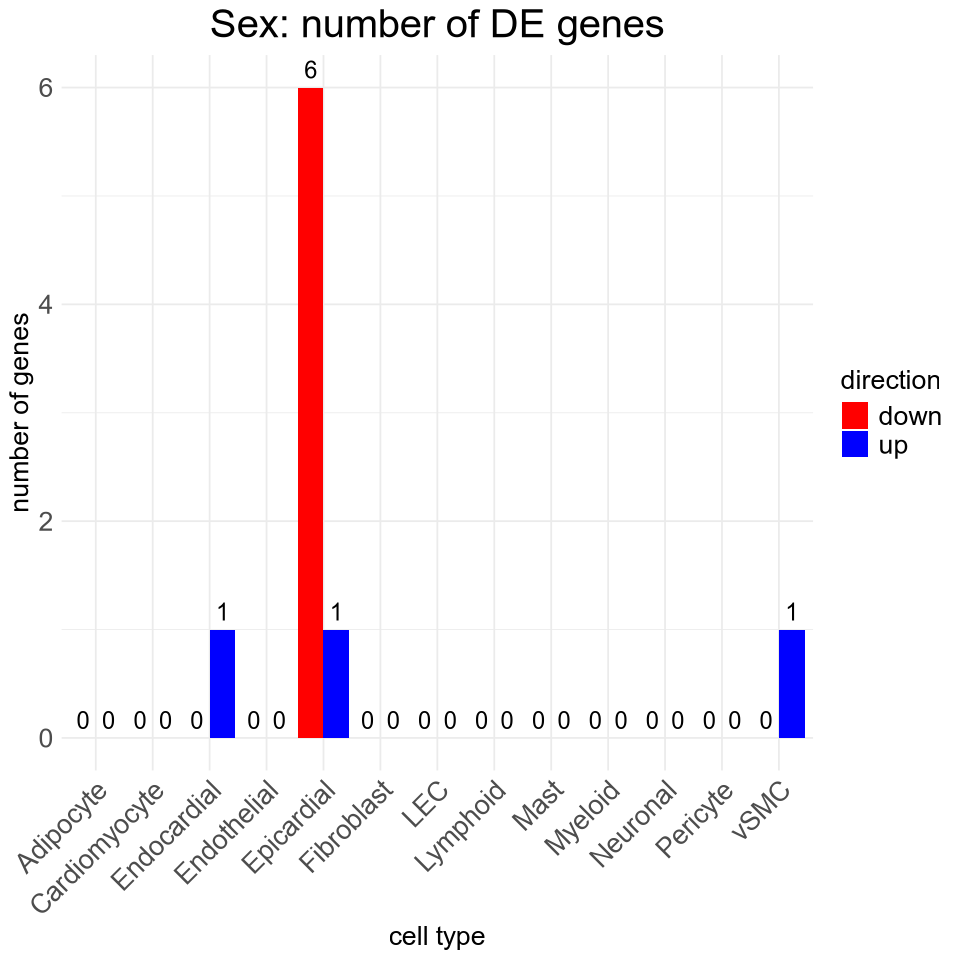

In [18]:
sex_plot <-  barplot_with_text(sex_tidy_df, "Sex: number of DE genes")
sex_plot